# Crime Type Prediction - Full ML Workflow


## 1. Setup


In [2]:
# If you already have these, you can skip this cell.
!pip -q install scikit-learn joblib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib


## 3. Load Data


In [4]:
csv_path = 'data/crime/2025-11-avon-and-somerset-street.csv'
assert os.path.exists(csv_path), f'File not found: {csv_path}'
df = pd.read_csv(csv_path)
print(f'Loaded {len(df):,} rows and {df.shape[1]} columns')
df.head()


Loaded 16,977 rows and 12 columns


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2025-11,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
1,NaN,2025-11,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,NaN
2,55480fb949f84b1a64db63a230f4fb7b4591f04c0251c8...,2025-11,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.513901,51.418814,On or near Stockwood Hill,E01014399,Bath and North East Somerset 001A,Burglary,Investigation complete; no suspect identified,NaN
3,eafac600ef57c5d440ee242ec6e89aa3d0823074fa71f1...,2025-11,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.509173,51.419104,On or near Durley Hill,E01014399,Bath and North East Somerset 001A,Burglary,Under investigation,NaN
4,a4c40dbd015f83c1023b27dae460cffd68833a8a4561b3...,2025-11,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.519070,51.416822,On or near Stockwood Vale,E01014399,Bath and North East Somerset 001A,Criminal damage and arson,Under investigation,NaN


## 4. Quick EDA


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 16977 entries, 0 to 16976
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               14923 non-null  str    
 1   Month                  16977 non-null  str    
 2   Reported by            16977 non-null  str    
 3   Falls within           16977 non-null  str    
 4   Longitude              16236 non-null  float64
 5   Latitude               16236 non-null  float64
 6   Location               16977 non-null  str    
 7   LSOA code              16236 non-null  str    
 8   LSOA name              16236 non-null  str    
 9   Crime type             16977 non-null  str    
 10  Last outcome category  14923 non-null  str    
 11  Context                0 non-null      float64
dtypes: float64(3), str(9)
memory usage: 1.6 MB


In [6]:
# Missing values (top 10)
(df.isna().mean().sort_values(ascending=False).head(10) * 100).round(2)


Context                  100.00
Crime ID                  12.10
Last outcome category     12.10
Longitude                  4.36
LSOA name                  4.36
LSOA code                  4.36
Latitude                   4.36
Month                      0.00
Falls within               0.00
Reported by                0.00
dtype: float64

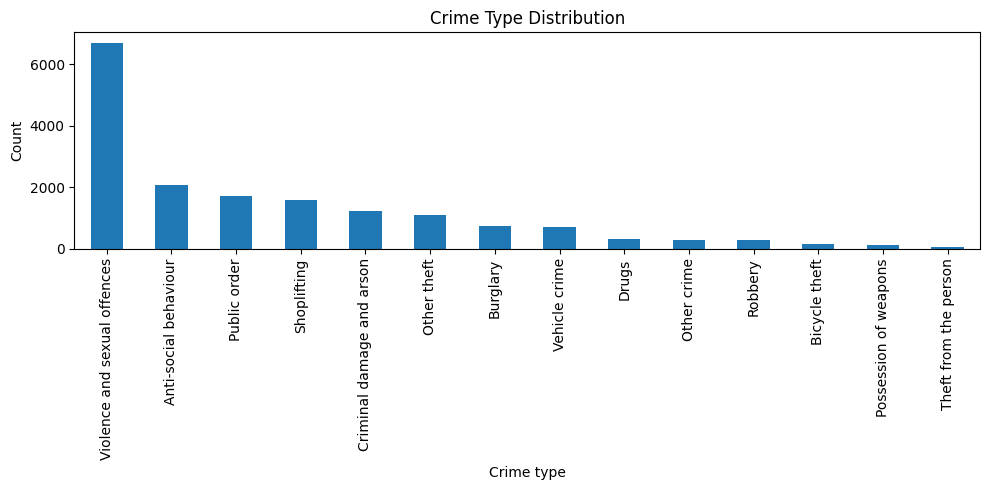

In [7]:
# Target distribution
plt.figure(figsize=(10, 5))
df['Crime type'].value_counts().plot(kind='bar')
plt.title('Crime Type Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## 5. Cleaning + Feature Engineering


In [8]:
# Drop duplicates
df = df.drop_duplicates().copy()

# Drop rows with missing target
df = df.dropna(subset=['Crime type']).copy()

# Drop columns with >95% missing values
missing_ratio = df.isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.95].index.tolist()
if high_missing_cols:
    print('Dropping high-missing columns:', high_missing_cols)
    df = df.drop(columns=high_missing_cols)

# Feature engineering: split Month into year/month
if 'Month' in df.columns:
    df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m', errors='coerce')
    df['year'] = df['Month'].dt.year
    df['month_num'] = df['Month'].dt.month
    df = df.drop(columns=['Month'])

# Drop Crime ID (typically unique / not predictive)
if 'Crime ID' in df.columns:
    df = df.drop(columns=['Crime ID'])

df.head()


Dropping high-missing columns: ['Context']


,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,year,month_num
0,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.492876,51.422716,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Anti-social behaviour,NaN,2025,11
2,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.513901,51.418814,On or near Stockwood Hill,E01014399,Bath and North East Somerset 001A,Burglary,Investigation complete; no suspect identified,2025,11
3,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.509173,51.419104,On or near Durley Hill,E01014399,Bath and North East Somerset 001A,Burglary,Under investigation,2025,11
4,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.519070,51.416822,On or near Stockwood Vale,E01014399,Bath and North East Somerset 001A,Criminal damage and arson,Under investigation,2025,11
5,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.513393,51.409357,On or near Charlton Road,E01014399,Bath and North East Somerset 001A,Possession of weapons,Under investigation,2025,11


## 6. Train/Test Split


In [9]:
target = 'Crime type'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)


Train size: (13076, 10)
Test size: (3269, 10)


## 7. Preprocessing + Feature Selection


In [10]:
# Identify numeric vs categorical columns
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)


Numeric features: ['Longitude', 'Latitude', 'year', 'month_num']
Categorical features: ['Reported by', 'Falls within', 'Location', 'LSOA code', 'LSOA name', 'Last outcome category']


In [11]:
# OneHotEncoder compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())  # chi2 requires non-negative values
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## 8. Model Comparison (Best Accuracy)


In [12]:
# Determine a safe k for SelectKBest based on preprocessed feature count
X_train_pre = preprocessor.fit_transform(X_train)
n_features = X_train_pre.shape[1]
k = min(300, n_features)
print('Total features after preprocessing:', n_features)
print('SelectKBest k:', k)

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, n_jobs=-1, solver='saga')
    , 'LinearSVC': LinearSVC()
    , 'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor)
        , ('select', SelectKBest(score_func=chi2, k=k))
        , ('model', model)
    ])
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
        n_jobs=-1
    )
    results.append({
        'model': name,
        'f1_macro': scores['test_f1_macro'].mean(),
        'accuracy': scores['test_accuracy'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='f1_macro', ascending=False)
results_df


Total features after preprocessing: 6751
SelectKBest k: 300


,model,f1_macro,accuracy
2,RandomForest,0.106433,0.440961
1,LinearSVC,0.104728,0.442260
0,LogisticRegression,0.097233,0.448608


## 9. Train Best Model + Evaluate


Best model: RandomForest
                              precision    recall  f1-score   support

       Anti-social behaviour       0.12      0.01      0.02       291
               Bicycle theft       0.20      0.04      0.06        27
                    Burglary       0.39      0.05      0.09       144
   Criminal damage and arson       0.31      0.02      0.03       246
                       Drugs       0.43      0.05      0.09        60
                 Other crime       0.33      0.03      0.06        58
                 Other theft       0.18      0.04      0.07       221
       Possession of weapons       0.00      0.00      0.00        22
                Public order       0.22      0.01      0.03       343
                     Robbery       0.00      0.00      0.00        54
                 Shoplifting       0.57      0.53      0.55       315
       Theft from the person       0.00      0.00      0.00        14
               Vehicle crime       0.00      0.00      0.00     

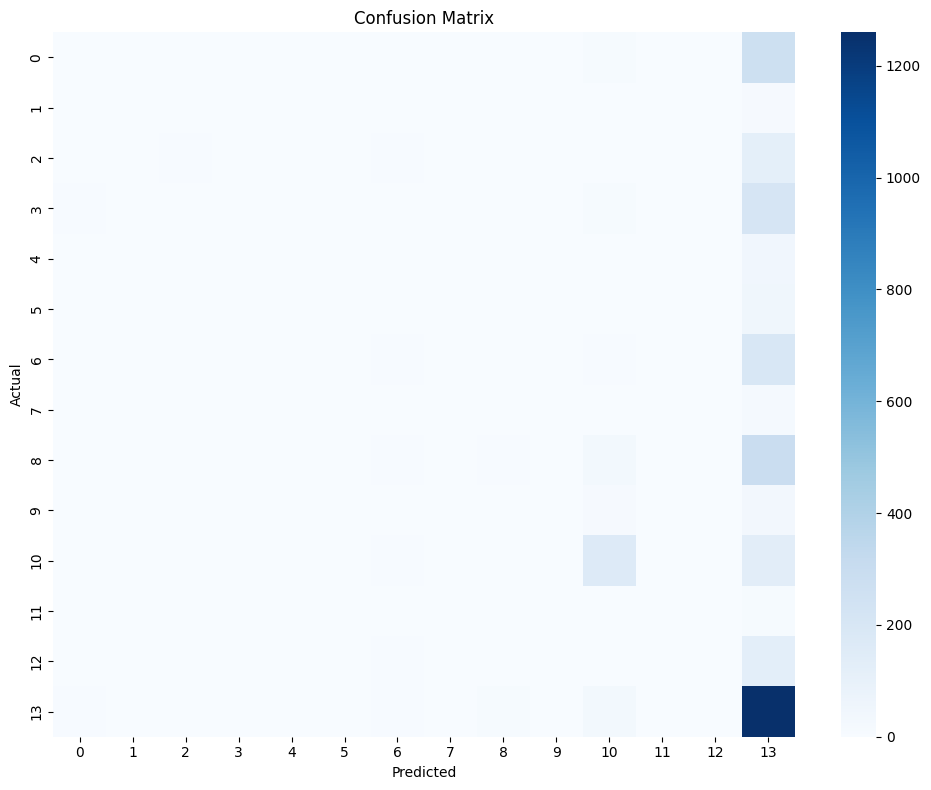

In [13]:
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]
print('Best model:', best_model_name)

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
    , ('select', SelectKBest(score_func=chi2, k=k))
    , ('model', best_model)
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 10. Save the Trained Model


In [14]:
os.makedirs('models', exist_ok=True)
model_path = 'models/crime_type_model.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Model saved to {model_path}')


Model saved to models/crime_type_model.joblib


## 11. Make Predictions (Sample)


In [15]:
sample = X_test.head(10)
preds = best_pipeline.predict(sample)
pd.DataFrame({
    'Predicted Crime Type': preds
}, index=sample.index).head(10)


,Predicted Crime Type
14368,Violence and sexual offences
1947,Shoplifting
7617,Other theft
12770,Violence and sexual offences
348,Violence and sexual offences
15856,Violence and sexual offences
11253,Violence and sexual offences
3263,Violence and sexual offences
5662,Violence and sexual offences
3992,Violence and sexual offences
